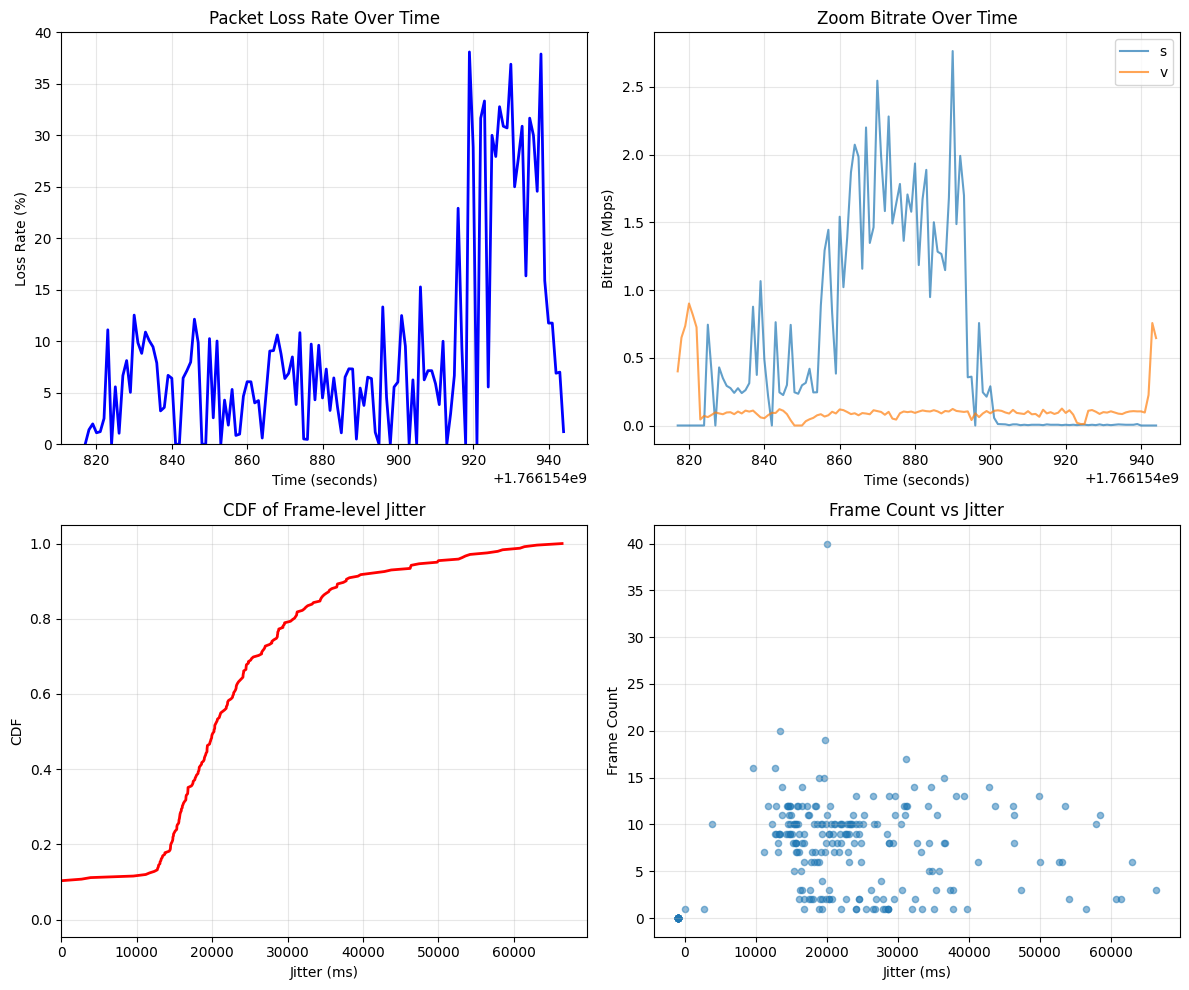

ZOOM PERFORMANCE SUMMARY

1. OVERALL STATISTICS:
   • Total packets: 11,146
   • Lost packets: 376
   • Average loss rate: 9.37%

2. JITTER STATISTICS:
   • Mean jitter: 22092.62 ms
   • 95th percentile: 49720.12 ms
   • Max jitter: 66400.70 ms

3. BITRATE STATISTICS:
   • Average bitrate: 0.38 Mbps
   • Peak bitrate: 2.76 Mbps

4. BY MEDIA TYPE:
   • v:
     - Loss rate: 8.50%
     - Avg jitter: 17159.08 ms
     - Avg bitrate: 0.12 Mbps
   • s:
     - Loss rate: 10.39%
     - Avg jitter: 27819.06 ms
     - Avg bitrate: 0.67 Mbps

✓ Results saved:
  - loss_rate_over_time.csv
  - zoom_analysis_results.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("stats.csv")

# Clean data
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 1. LOSS RATE ANALYSIS
# Compute loss rate per packet
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Loss rate over time (1-second bins)
loss_over_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()
loss_over_time.to_csv("loss_rate_over_time.csv", index=False)

# 2. BITRATE ANALYSIS (Section 5.1)
if 'bytes' in df.columns:
    df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6  # Convert to Mbps
    
    # Bitrate over time
    if 'media_type' in df.columns:
        bitrate_by_type = df.groupby(['ts_s', 'media_type'])['bitrate_mbps'].sum().unstack().fillna(0)
    else:
        bitrate_by_type = df.groupby('ts_s')['bitrate_mbps'].sum()

# 3. JITTER ANALYSIS (Section 5.4)
if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000  # Convert to ms

# 4. PLOTS
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Loss rate over time
axes[0,0].plot(loss_over_time['ts_s'], loss_over_time['loss_rate'] * 100, 'b-', linewidth=2)
axes[0,0].set_xlabel('Time (seconds)')
axes[0,0].set_ylabel('Loss Rate (%)')
axes[0,0].set_title('Packet Loss Rate Over Time')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(0)

# Plot 2: Bitrate over time
if 'bitrate_mbps' in df.columns:
    if 'media_type' in df.columns and isinstance(bitrate_by_type, pd.DataFrame):
        for media_type in bitrate_by_type.columns:
            axes[0,1].plot(bitrate_by_type.index, bitrate_by_type[media_type], 
                          label=media_type, alpha=0.7)
        axes[0,1].legend()
    else:
        axes[0,1].plot(bitrate_by_type.index, bitrate_by_type.values, 'g-', alpha=0.7)
    axes[0,1].set_xlabel('Time (seconds)')
    axes[0,1].set_ylabel('Bitrate (Mbps)')
    axes[0,1].set_title('Zoom Bitrate Over Time')
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Jitter CDF
if 'jitter_ms' in df.columns:
    jitter_data = df['jitter_ms'].dropna()
    sorted_jitter = np.sort(jitter_data)
    cdf = np.arange(1, len(sorted_jitter) + 1) / len(sorted_jitter)
    axes[1,0].plot(sorted_jitter, cdf, 'r-', linewidth=2)
    axes[1,0].set_xlabel('Jitter (ms)')
    axes[1,0].set_ylabel('CDF')
    axes[1,0].set_title('CDF of Frame-level Jitter')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].set_xlim(0)

# Plot 4: Scatter: Jitter vs Frames
if 'frames' in df.columns and 'jitter_ms' in df.columns:
    sample_size = min(500, len(df))
    plot_df = df.sample(sample_size) if len(df) > sample_size else df
    axes[1,1].scatter(plot_df['jitter_ms'], plot_df['frames'], alpha=0.5, s=20)
    axes[1,1].set_xlabel('Jitter (ms)')
    axes[1,1].set_ylabel('Frame Count')
    axes[1,1].set_title('Frame Count vs Jitter')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zoom_analysis_results.png', dpi=150)
plt.show()

# 5. SUMMARY STATISTICS
print("=" * 50)
print("ZOOM PERFORMANCE SUMMARY")
print("=" * 50)

# Overall statistics
print(f"\n1. OVERALL STATISTICS:")
print(f"   • Total packets: {df['pkts'].sum():,.0f}")
print(f"   • Lost packets: {df['lost'].sum():,.0f}")
print(f"   • Average loss rate: {df['loss_rate'].mean()*100:.2f}%")

# Jitter stats
if 'jitter_ms' in df.columns:
    print(f"\n2. JITTER STATISTICS:")
    print(f"   • Mean jitter: {df['jitter_ms'].mean():.2f} ms")
    print(f"   • 95th percentile: {np.percentile(df['jitter_ms'].dropna(), 95):.2f} ms")
    print(f"   • Max jitter: {df['jitter_ms'].max():.2f} ms")

# Bitrate stats
if 'bitrate_mbps' in df.columns:
    print(f"\n3. BITRATE STATISTICS:")
    print(f"   • Average bitrate: {df['bitrate_mbps'].mean():.2f} Mbps")
    print(f"   • Peak bitrate: {df['bitrate_mbps'].max():.2f} Mbps")

# By media type if available
if 'media_type' in df.columns:
    print(f"\n4. BY MEDIA TYPE:")
    for media_type in df['media_type'].unique():
        media_df = df[df['media_type'] == media_type]
        print(f"   • {media_type}:")
        print(f"     - Loss rate: {media_df['loss_rate'].mean()*100:.2f}%")
        if 'jitter_ms' in df.columns:
            print(f"     - Avg jitter: {media_df['jitter_ms'].mean():.2f} ms")
        if 'bitrate_mbps' in df.columns:
            print(f"     - Avg bitrate: {media_df['bitrate_mbps'].mean():.2f} Mbps")

print(f"\n✓ Results saved:")
print(f"  - loss_rate_over_time.csv")
print(f"  - zoom_analysis_results.png")
print("=" * 50)



# audio screenshare with two users 